## BSHD & MBH Seg25 Overlay

In [1]:
import re
from pathlib import Path
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
# Data root
DATA_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data")

In [ ]:
class_names = {1: 'EDH', 2: 'IPH', 3: 'IVH', 4: 'SAH', 5: 'SDH'}
class_colors = {
    1: (198, 68, 66),
    2: (76, 71, 199),
    3: (171, 43, 171),
    4: (168, 181, 112),
    5: (4, 136, 133),
}

n_classes = max(class_colors) + 1
colors_rgb = np.zeros((n_classes, 3))
for cls, rgb in class_colors.items():
    colors_rgb[cls] = np.array(rgb) / 255.0
custom_cmap = ListedColormap(colors_rgb)

In [4]:
def find_bhsd_case(patient_id):
    img_dir = DATA_ROOT / "bhsd" / "label_192" / "images"
    mask_dir = DATA_ROOT / "bhsd" / "label_192" / "ground truths"
    matches = list(img_dir.glob(f"ID_{patient_id}_*.nii.gz"))
    if not matches:
        raise FileNotFoundError(f"BHSD case not found for patient {patient_id}")
    img_path = matches[0]
    mask_path = mask_dir / img_path.name
    return img_path, mask_path

In [ ]:
def find_mbh_case(patient_id, annotator_id=3):
    for split in ["train", "val"]:
        root = DATA_ROOT / "mbhseg25" / split
        matches = [d for d in root.iterdir() if d.is_dir() and d.name.startswith(f"ID_{patient_id}_")]
        if matches:
            case_dir = matches[0]
            img_path = case_dir / "image.nii.gz"
            mask_path = case_dir / f"label_annot_{annotator_id}.nii.gz"
            if not mask_path.exists():
                for aid in [3, 2, 1, 4]:
                    alt = case_dir / f"label_annot_{aid}.nii.gz"
                    if alt.exists():
                        mask_path = alt
                        break
            return img_path, mask_path
    raise FileNotFoundError(f"MBHSeg25 case not found for patient {patient_id}")

In [6]:
def apply_window(slice_hu, window_level=40, window_width=80):
    lo, hi = window_level - window_width / 2, window_level + window_width / 2
    return (np.clip(slice_hu, lo, hi) - lo) / (hi - lo)

def load_reoriented(img_path, mask_path, orientation="LPS"):
    img = sitk.DICOMOrient(sitk.ReadImage(str(img_path)), orientation)
    mask = sitk.DICOMOrient(sitk.ReadImage(str(mask_path)), orientation)
    img_arr = sitk.GetArrayFromImage(img)    # (z, y, x)
    mask_arr = sitk.GetArrayFromImage(mask)
    return img_arr, mask_arr

### BHSD & MBH-Seg25 Compare 

In [ ]:
def compare_case(patient_id, z=None, annotator_id=3, orientation="LPS"):
    bhsd_img_path, bhsd_mask_path = find_bhsd_case(patient_id)
    mbh_img_path, mbh_mask_path = find_mbh_case(patient_id, annotator_id)

    bhsd_img, bhsd_mask = load_reoriented(bhsd_img_path, bhsd_mask_path, orientation)
    mbh_img, mbh_mask = load_reoriented(mbh_img_path, mbh_mask_path, orientation)

    if z is None:
        # 두 데이터 각각에서 병변 voxel이 가장 많은 z를 선택 (데이터셋마다 slice 수/annotator가 달라 z가 완전히 동일하지 않을 수 있음)
        z_bhsd = int((bhsd_mask > 0).sum(axis=(1, 2)).argmax())
        z_mbh = int((mbh_mask > 0).sum(axis=(1, 2)).argmax())
    else:
        z_bhsd = z_mbh = z

    rows = [
        ("BHSD", bhsd_img, bhsd_mask, z_bhsd, bhsd_img_path.name),
        ("MBHSeg25", mbh_img, mbh_mask, z_mbh, f"{mbh_mask_path.parent.name} ({mbh_mask_path.name})"),
    ]

    fig, axes = plt.subplots(len(rows), 3, figsize=(15, 5 * len(rows)))
    for row_idx, (name, img_arr, mask_arr, zz, case_name) in enumerate(rows):
        windowed = apply_window(img_arr[zz])
        mask_slice = mask_arr[zz]
        mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

        ax_img, ax_mask, ax_overlay = axes[row_idx]

        ax_img.imshow(windowed, cmap='gray', vmin=0, vmax=1)
        ax_img.set_title(f"{name} CT (z={zz})")
        ax_img.text(0.02, 0.98, case_name, transform=ax_img.transAxes,
                     va='top', ha='left', color='white', fontsize=8)
        ax_img.axis('off')

        ax_mask.imshow(mask_slice, cmap=custom_cmap, vmin=0, vmax=n_classes - 1)
        ax_mask.set_title(f"{name} mask")
        ax_mask.axis('off')

        ax_overlay.imshow(windowed, cmap='gray', vmin=0, vmax=1)
        ax_overlay.imshow(mask_overlay, cmap=custom_cmap, vmin=0, vmax=n_classes - 1, alpha=0.6)
        ax_overlay.set_title(f"{name} overlay")
        ax_overlay.axis('off')

    handles = [plt.Rectangle((0, 0), 1, 1, color=np.array(class_colors[c]) / 255) for c in sorted(class_colors)]
    labels = [class_names[c] for c in sorted(class_colors)]
    fig.legend(handles, labels, loc='lower center', ncol=len(labels))
    fig.suptitle(f"Patient {patient_id}: BHSD vs MBHSeg25 mask comparison", fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()

/tmp/ipykernel_1023630/3713880886.py:47: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.05, 1, 0.96])
/tmp/ipykernel_1023630/3713880886.py:47: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.05, 1, 0.96])


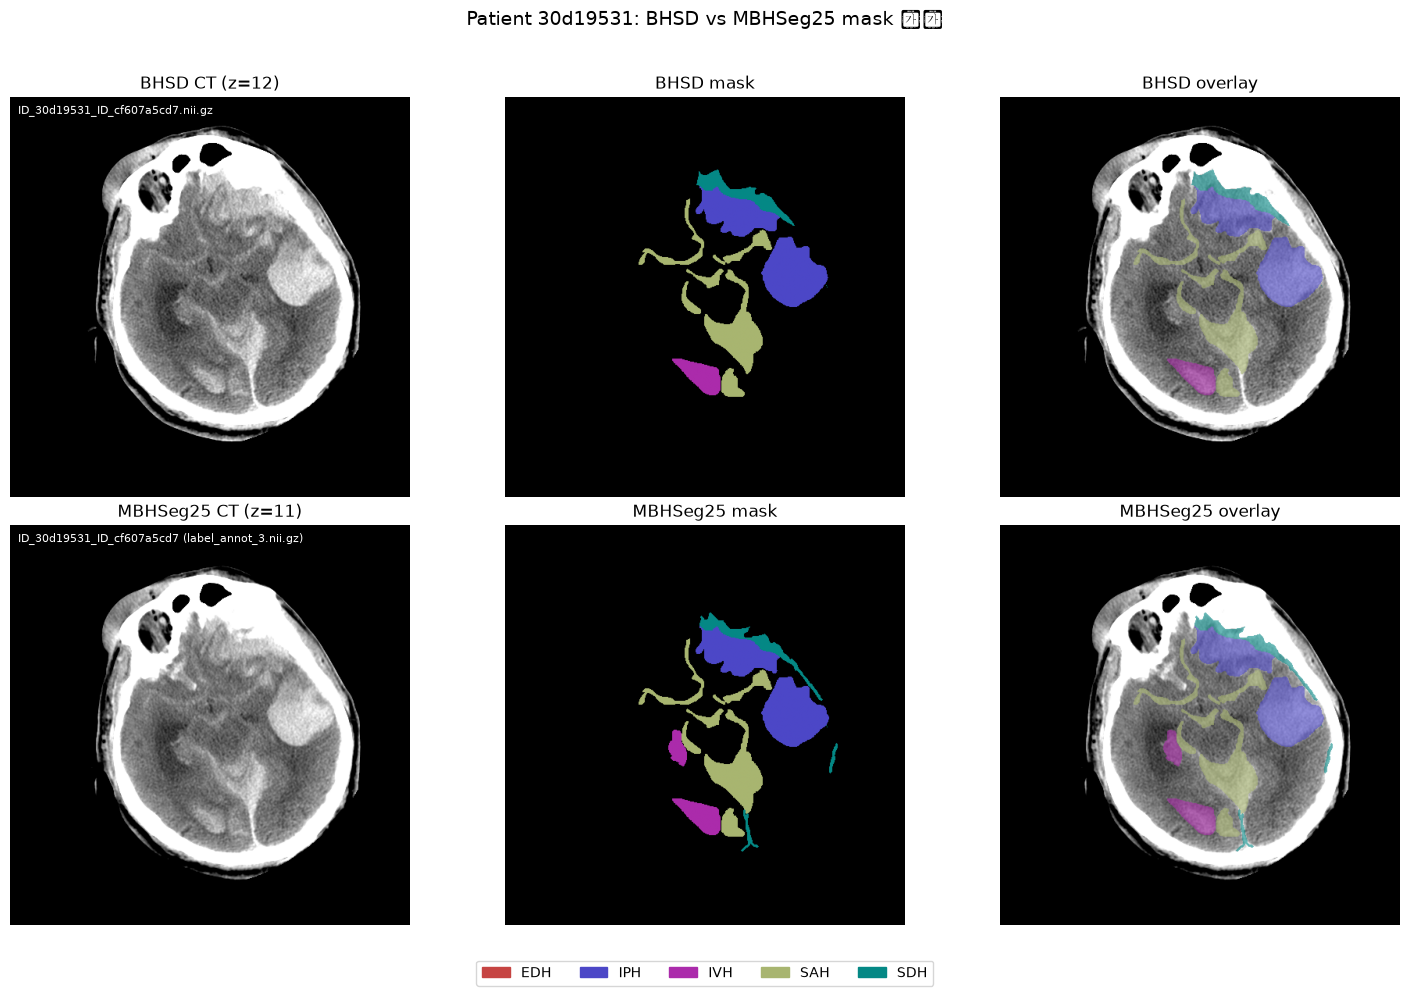

In [14]:
compare_case("30d19531")

### MBH annotator comparison

In [21]:
def find_mbh_case_dir(patient_id):
    for split in ["train", "val"]:
        root = DATA_ROOT / "mbhseg25" / split
        matches = [d for d in root.iterdir() if d.is_dir() and d.name.startswith(f"ID_{patient_id}_")]
        if matches:
            return matches[0], split
    raise FileNotFoundError(f"MBHSeg25 case not found for patient {patient_id}")


def find_mbh_case(patient_id, annotator_id=3):
    case_dir, _ = find_mbh_case_dir(patient_id)
    img_path = case_dir / "image.nii.gz"
    mask_path = case_dir / f"label_annot_{annotator_id}.nii.gz"
    if not mask_path.exists():
        for aid in [3, 2, 1, 4]:
            alt = case_dir / f"label_annot_{aid}.nii.gz"
            if alt.exists():
                mask_path = alt
                break
    return img_path, mask_path

def find_available_annotators(case_dir):
    annot_paths = sorted(case_dir.glob("label_annot_*.nii.gz"))
    annots = {}
    for p in annot_paths:
        m = re.search(r"label_annot_(\d+)\.nii\.gz", p.name)
        if m:
            annots[int(m.group(1))] = p
    return annots

In [26]:
def compare_annotators(patient_id, z=None, orientation="LPS"):
    case_dir, split = find_mbh_case_dir(patient_id)
    img_path = case_dir / "image.nii.gz"
    annot_paths = find_available_annotators(case_dir)
    if not annot_paths:
        raise FileNotFoundError(f"{case_dir}에 annotator mask가 없습니다")

    img = sitk.DICOMOrient(sitk.ReadImage(str(img_path)), orientation)
    img_arr = sitk.GetArrayFromImage(img)  # (z, y, x)

    annot_arrs = {}
    for aid, p in annot_paths.items():
        mask = sitk.DICOMOrient(sitk.ReadImage(str(p)), orientation)
        annot_arrs[aid] = sitk.GetArrayFromImage(mask)

    # 모든 annotator의 foreground voxel 합이 가장 큰 z를 대표 슬라이스로 선택 (한쪽만 병변 있는 케이스도 놓치지 않기 위해 합산)
    if z is None:
        union_fg = np.zeros(img_arr.shape[0])
        for arr in annot_arrs.values():
            union_fg += (arr > 0).sum(axis=(1, 2))
        z = int(union_fg.argmax())

    windowed = apply_window(img_arr[z])
    aids = sorted(annot_arrs)

    fig, axes = plt.subplots(
        1, len(aids) + 1,
        figsize=(5 * (len(aids) + 1), 5),
        gridspec_kw={'wspace': 0.02},
    )

    axes[0].imshow(windowed, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f"CT (z={z})")
    axes[0].text(0.02, 0.98, f"{case_dir.name} ({split})", transform=axes[0].transAxes,
                 va='top', ha='left', color='white', fontsize=8)
    axes[0].axis('off')

    for ax, aid in zip(axes[1:], aids):
        mask_slice = annot_arrs[aid][z]
        mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

        ax.imshow(windowed, cmap='gray', vmin=0, vmax=1)
        ax.imshow(mask_overlay, cmap=custom_cmap, vmin=0, vmax=n_classes - 1, alpha=0.6)
        ax.set_title(f"annotator #{aid}")
        ax.axis('off')

    handles = [plt.Rectangle((0, 0), 1, 1, color=np.array(class_colors[c]) / 255) for c in sorted(class_colors)]
    labels = [class_names[c] for c in sorted(class_colors)]
    fig.legend(handles, labels, loc='lower center', ncol=len(labels))
    fig.suptitle(f"Patient {patient_id} (MBHSeg25): annotator masking comparison", fontsize=14)

    plt.subplots_adjust(wspace=0.02, bottom=0.08, top=0.88)
    plt.show()


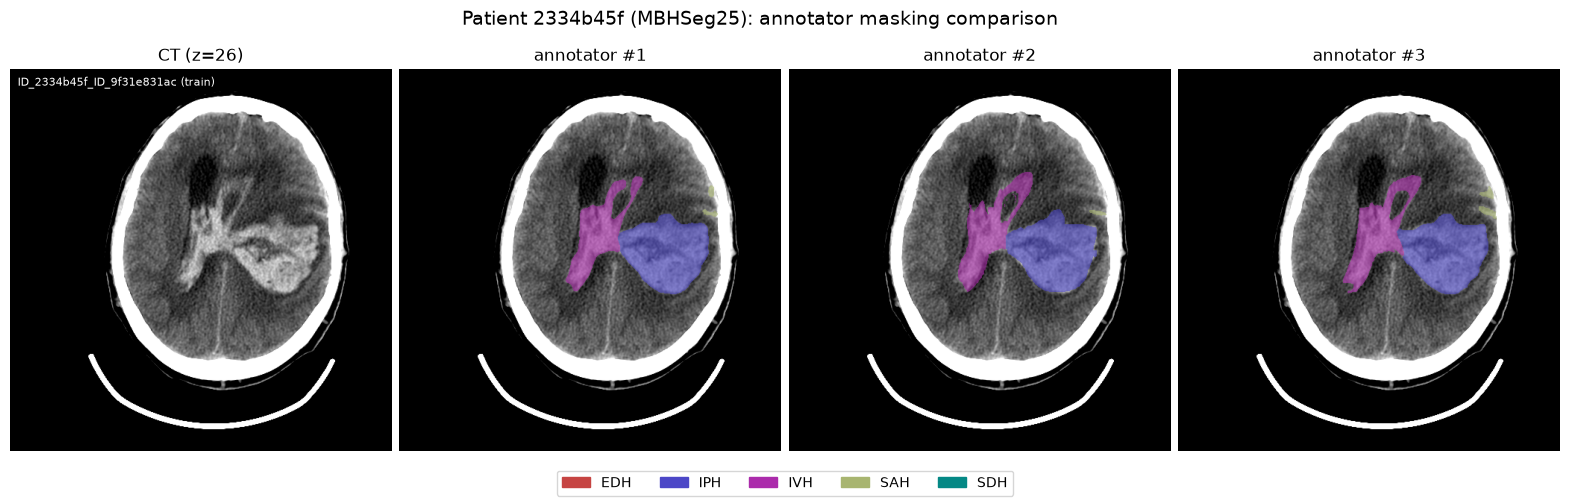

In [27]:
compare_annotators("2334b45f")